In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math
import sys
from scipy.optimize import minimize
mpl.rcParams.update({'font.size': 20})
mpl.rcParams.update({'axes.linewidth': 2})

## Models for fitting

In [2]:
# Define the model: falling power law
def power_law_basic(x, A, alpha):
    return A * x**(-alpha)

def power_law(x, A, alpha, x0, k):
    return A * x**(-alpha) / (1 + np.exp(-(x - x0)*k))

# Define the model: falling shifted power law
def shifted_power_law_basic(x, N, a, b):
    return N * (b - 1) * a**(b - 1) * (x + a)**(-b)

def shifted_power_law(x, N, a, b, x0, k):
    return N * (b - 1) * a**(b - 1) * (x + a)**(-b) / (1 + np.exp(-(x - x0)*k))
   
# Define the model: falling exponential
def exponential_basic(x, A, alpha):
    return A * np.exp(-x * alpha)

def exponential(x, A, alpha, x0, k):
    return A * np.exp(-x * alpha) / (1 + np.exp(-(x - x0)*k))

# Negative log likelihood function to minimize
def negative_log_likelihood_power(params, x, counts):
    A, alpha, x0, k = params
    y = power_law(x, A, alpha, x0, k)
    nll = np.sum(y - counts * np.log(y))
    return nll

# Negative log likelihood function to minimize
def negative_log_likelihood_shifted_power(params, x, counts):
    N, a, b, x0, k = params
    y = shifted_power_law(x, N, a, b, x0, k)
    nll = np.sum(y - counts * np.log(y))
    return nll

# Negative log likelihood function to minimize
def negative_log_likelihood_exp(params, x, counts):
    A, alpha, x0, k = params
    y = exponential(x, A, alpha, x0, k)
    nll = np.sum(y - counts * np.log(y))
    return nll

# Negative log likelihood function to minimize
def negative_log_likelihood_power_basic(params, x, counts):
    A, alpha = params
    y = power_law_basic(x, A, alpha)
    nll = np.sum(y - counts * np.log(y))
    return nll

# Negative log likelihood function to minimize
def negative_log_likelihood_shifted_power_basic(params, x, counts):
    N, a, b = params
    y = shifted_power_law_basic(x, N, a, b)
    nll = np.sum(y - counts * np.log(y))
    return nll

# Negative log likelihood function to minimize
def negative_log_likelihood_exp_basic(params, x, counts):
    A, alpha = params
    y = exponential_basic(x, A, alpha)
    nll = np.sum(y - counts * np.log(y))
    return nll


## Getting fit parameters for exponential and power laws

### Loading data

In [3]:
# Mass [kg] = Volume [cm3] x Density [g/cm3] x Unit conversion [kg/g]
mass_kg = (1 * 1 * 0.1) * 2.329 * 1e-3
time_days = 12 / 24 * 0.612 # 12 hours of data, 0.612 passage fraciton
time_sec = time_days * 86400
print(f'{mass_kg * 1000:.4f} grams of Si')


0.2329 grams of Si


151080 events
Check unit conversion: integral = 128136.0 events, and real data = 151080 events
128737 events
Check unit conversion: integral = 99424.0 events, and real data = 128737 events
165935 events
Check unit conversion: integral = 125219.0 events, and real data = 165935 events


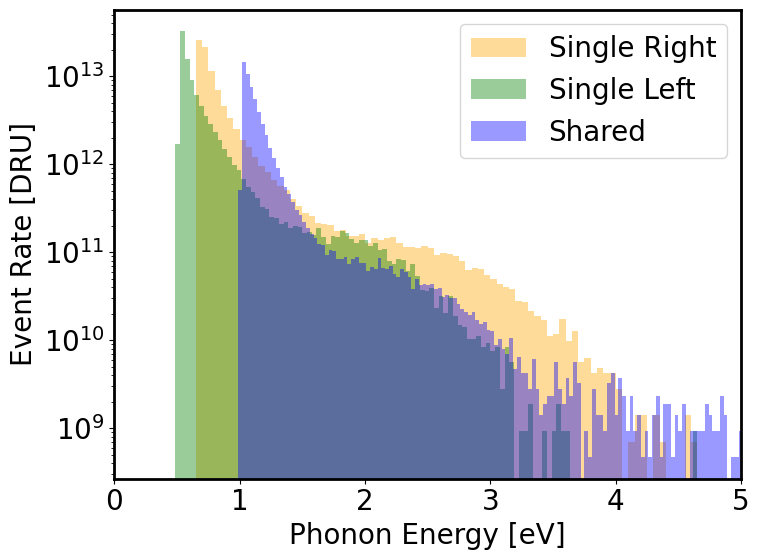

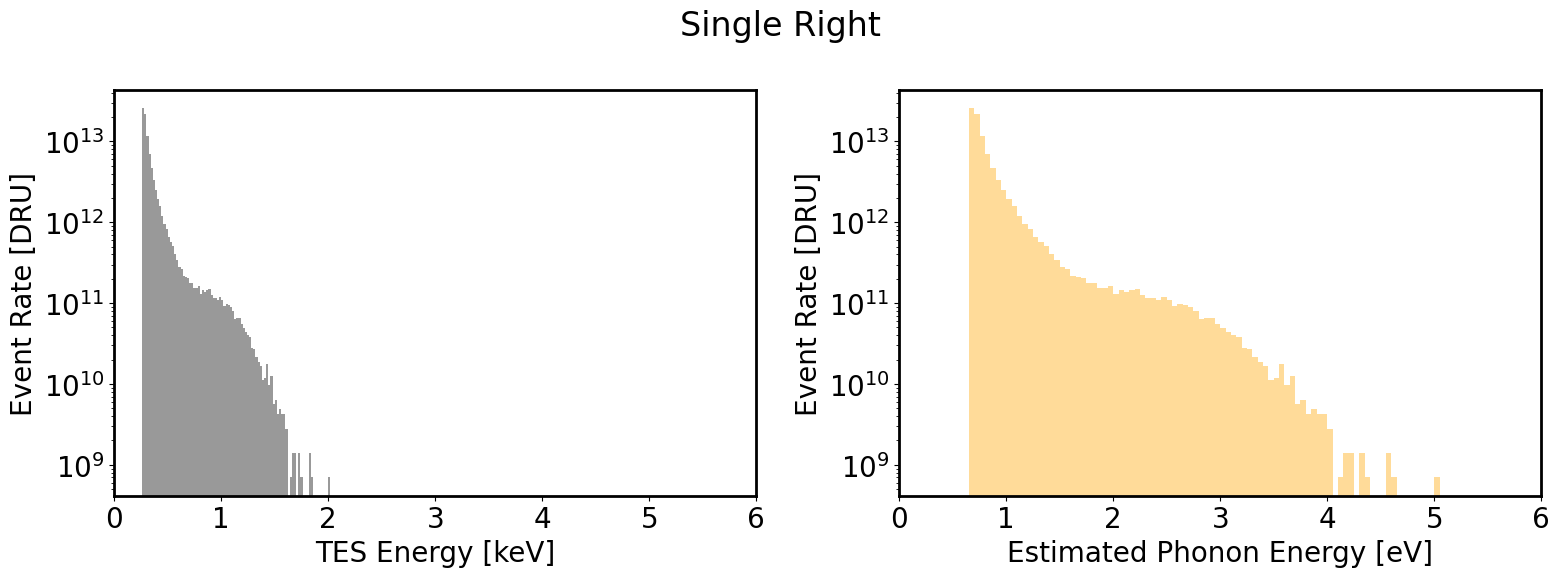

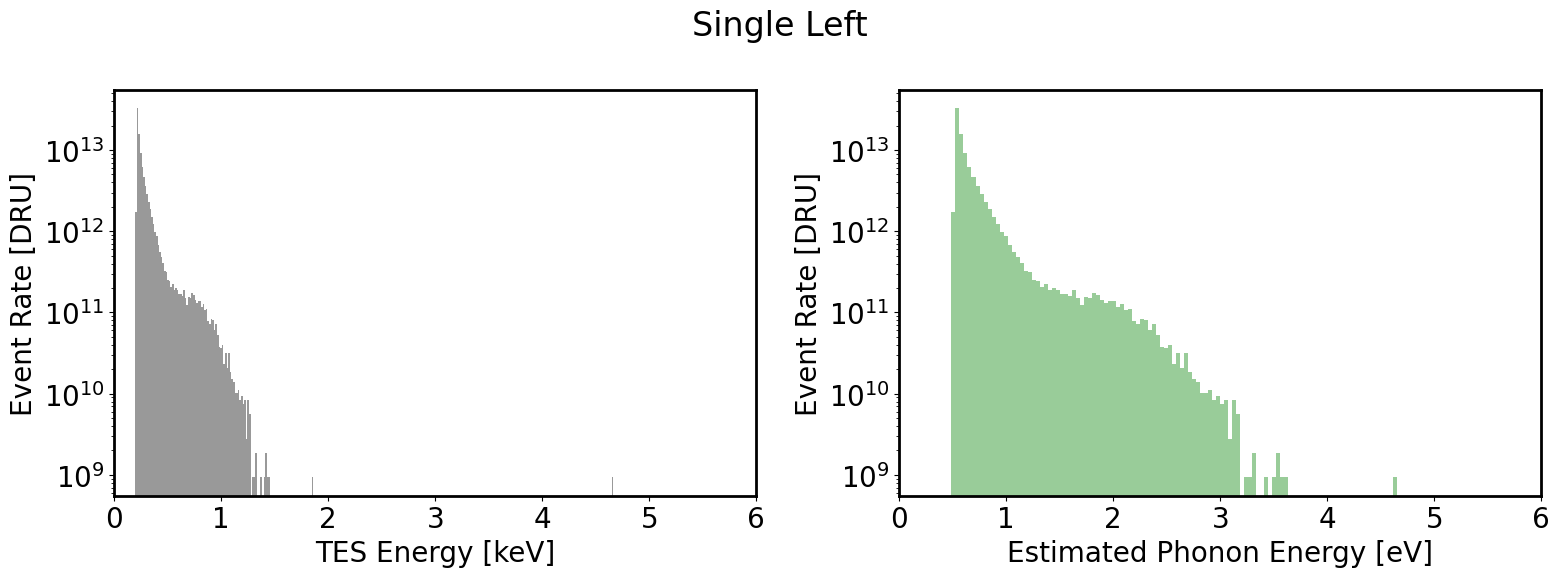

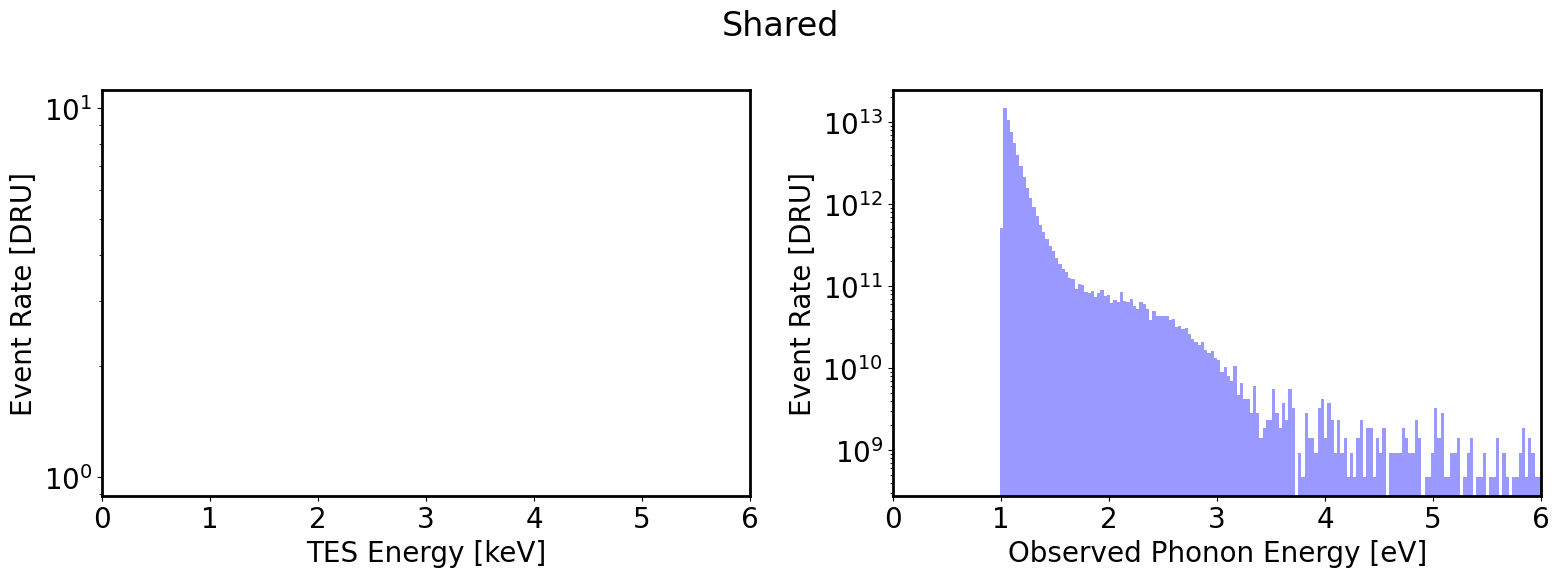

In [4]:
fig_all, ax_all = plt.subplots(1, 1, figsize=(8, 6))

for i, (fn, label, color) in enumerate(zip(
    ['spectra/r57_1226_1mm_single_right.npy', 'spectra/r57_1226_1mm_single_left.npy', 'spectra/r57_1226_1mm_shared.npy'],
    ['Single Right', 'Single Left', 'Shared'],
    ['orange', 'green', 'blue']
    )):
    
    energies_eV = np.load(fn)
    energies_keV = energies_eV / 1000
    print(f'{len(energies_eV)} events')

    if label == 'Single Right':
        pce = 0.4
        bins_eV_full = np.arange(0, max(energies_eV) + 4, 0.02)
    elif label == 'Single Left':
        pce = 0.4
        bins_eV_full = np.arange(0, max(energies_eV) + 4, 0.015)
    else:
        pce = 1.
        bins_eV_full = np.arange(0, max(energies_eV) + 4, 0.03)
        
    bins_keV_full = bins_eV_full / 1000

    event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

    ####### Plotting #######

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    ax[1].hist(energies_keV * 1e3 / pce, bins_keV_full * 1e3 / pce, weights=event_weights_DRU, alpha=0.4, color=color)
    
    if label == 'Shared':
        ax[1].set_xlabel('Observed Phonon Energy [eV]')
    else:
        ax[0].hist(energies_keV * 1e3, bins_keV_full * 1e3, weights=event_weights_DRU, alpha=0.4, color='k')
        ax[1].set_xlabel('Estimated Phonon Energy [eV]')
       
    for j in range(2):
        ax[j].set_xlim([0, 6])
        ax[j].set_yscale('log')
        ax[j].set_ylabel('Event Rate [DRU]')

    ax[0].set_xlabel('TES Energy [keV]')
    
    fig.suptitle(label)
    fig.tight_layout()
    fig.show()

    ax_all.hist(energies_keV * 1e3 / pce, bins_keV_full * 1e3 / pce, weights=event_weights_DRU, alpha=0.4, label=label, color=color)

    ####### Check unit conversion #######

    bin_counts, bin_edges = np.histogram(energies_keV, bins_keV_full, weights=event_weights_DRU)
    norm = sum(bin_counts * np.diff(bin_edges) * mass_kg * time_days)
    print(f'Check unit conversion: integral = {norm:.1f} events, and real data = {len(energies_eV)} events')

ax_all.set_yscale('log')
ax_all.set_xlabel('Phonon Energy [eV]')
ax_all.set_ylabel('Event Rate [DRU]')
ax_all.set_xlim([0, 5])
ax_all.legend(loc='upper right')
fig_all.tight_layout()
fig_all.show()

## Low-Energy Shared Fit

In [5]:
energies_eV = np.load('spectra/r57_1226_1mm_shared.npy')
energies_keV = energies_eV / 1000

bins_eV_full = np.arange(0.5, 5, 0.02)
bins_keV_full = bins_eV_full / 1000

# Do the fit in eV, then convert to keV (it converges better this way)
fit_low, fit_high = 0.9, 1.7
bins_eV_fit = bins_eV_full[(bins_eV_full > fit_low) * (bins_eV_full < fit_high)]

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

In [6]:
dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_fit, weights=event_weights_DRU)
counts_arr, _ = np.histogram(energies_eV, bins_eV_fit)

E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
E_keV_arr = E_eV_arr / 1000

Power law parameters (raw): A = 3.031e+00, alpha = -11.4736
Threshold = 1.016e+00 eV, inverse width = 5.00000e+02 1/eV
Power law parameters [in proper units]: A = 8.072e-22 DRU, alpha = -11.4736
Threshold = 1.016e-03 keV, width = 2.00000e-06 keV

Exponential parameters [raw]: A = 3.526e+01, inverse E0 = 9.4829e+00 1/eV
Threshold = 1.016e+00 eV, inverse width = 5.00006e+02 1/eV
Exponential parameters [in proper units]: A = 2.474e+17 DRU, E0 = 1.0545e-04 keV
Threshold = 1.016e-03 keV, width = 2.0000e-06 keV

Shifted Power law parameters [raw]: N = 1.475e+01, a = 1.2266 eV, b = 23.0620
Threshold = 1.016e+00 eV, inverse width = 5.00001e+02 1/eV
Shifted Power law parameters [in keV]: N = 1.035e+15 DRU, a = 0.0012 keV, b = 23.0620
Threshold = 1.016e-03 eV, width = 2.00000e-06 eV



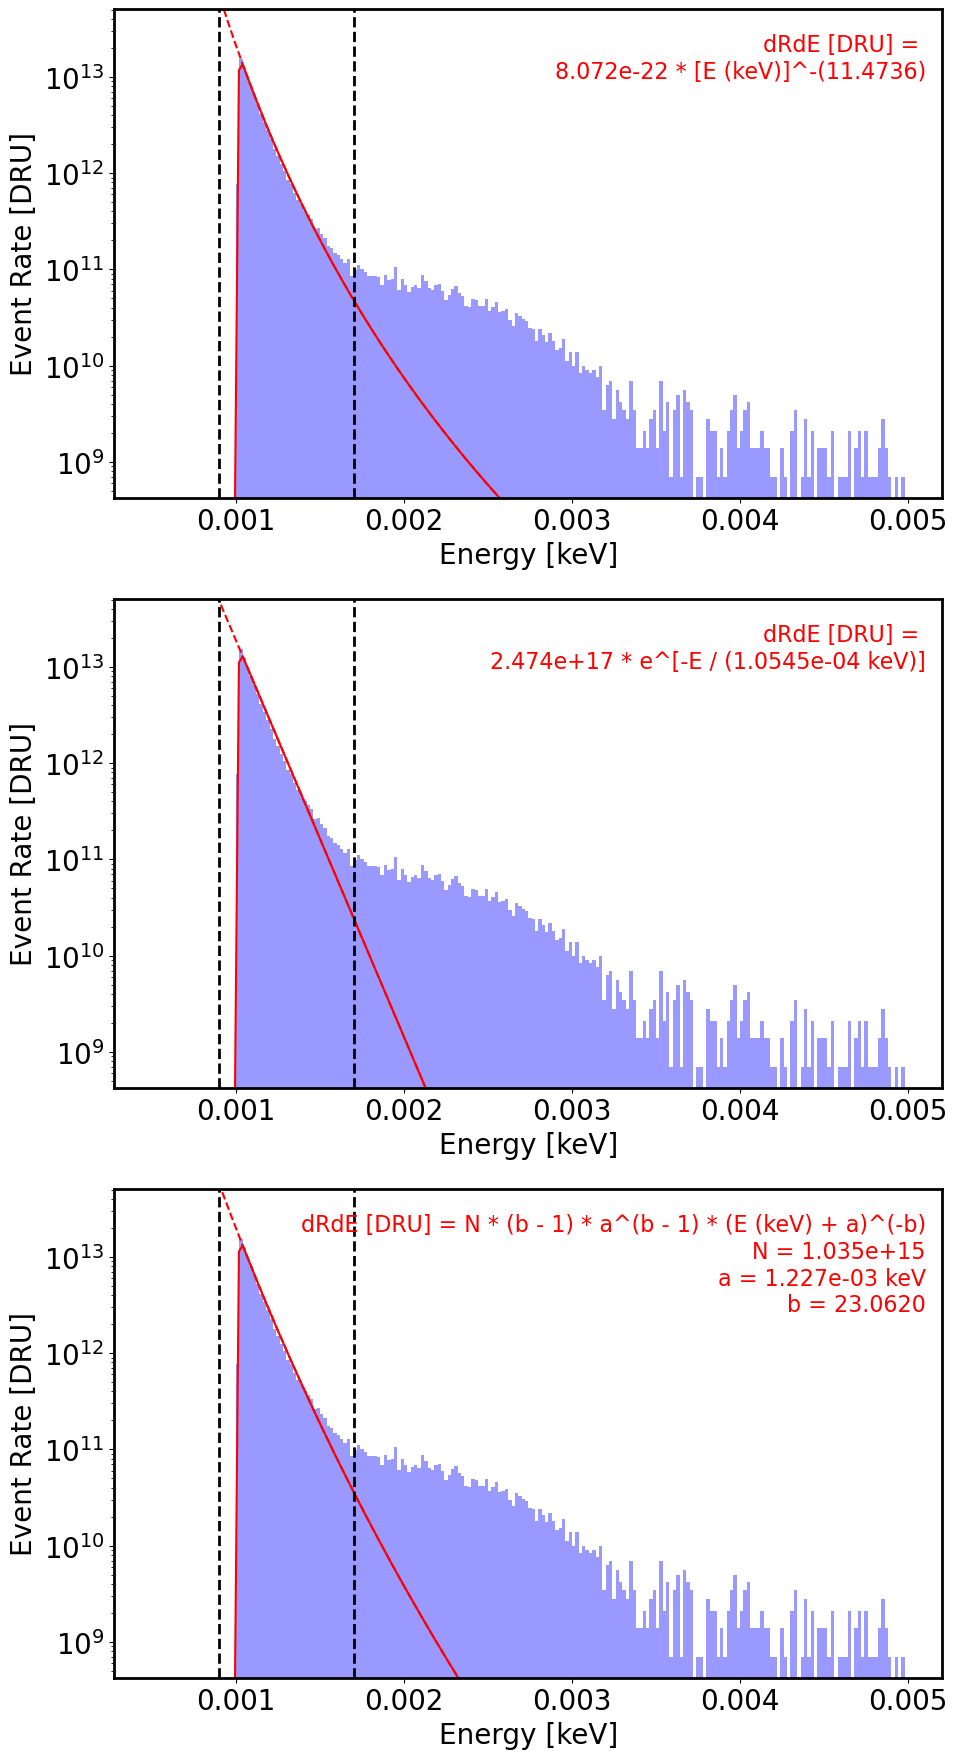

In [7]:
### Minimize the negative log likelihood for a power-law background
fit_scale = 1e4 # Divide the rate first to help the fit converge

# Do the fit in eV space to make it easier to fit, then convert to keV
result = minimize(negative_log_likelihood_power,
                  [1, 10, 1, 500],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None), (0.5, 1.5), (1e-10, None)])
A_fit_power, alpha_fit_power, Eth_power, inv_width_power = result.x
print(f"Power law parameters (raw): A = {A_fit_power:.3e}, alpha = -{alpha_fit_power:.4f}")
print(f'Threshold = {Eth_power:.3e} eV, inverse width = {inv_width_power:.5e} 1/eV')

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
A_fit_power *= fit_scale * 1000**(-1 * alpha_fit_power) * event_weights_DRU[0] 
Eth_power *= (1/1000)
inv_width_power *= 1000
print(f"Power law parameters [in proper units]: A = {A_fit_power:.3e} DRU, alpha = -{alpha_fit_power:.4f}")
print(f'Threshold = {Eth_power:.3e} keV, width = {1 / inv_width_power:.5e} keV')
print('')



### Minimize the negative log likelihood for a exponential background
fit_scale = 1e7 # Divide the rate first to help the fit converge

# Do the fit in eV space to make it easier to fit, then convert to keV
result = minimize(negative_log_likelihood_exp,
                  [1, 1, 1, 500],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None), (0.5, 1.5), (1e-10, None)])
A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp = result.x
print(f"Exponential parameters [raw]: A = {A_fit_exp:.3e}, inverse E0 = {inv_E0_exp:.4e} 1/eV")
print(f'Threshold = {Eth_exp:.3e} eV, inverse width = {inv_width_exp:.5e} 1/eV')

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
A_fit_exp *= fit_scale * event_weights_DRU[0]
inv_E0_exp *= 1000
Eth_exp *= (1/1000)
inv_width_exp *= 1000
print(f"Exponential parameters [in proper units]: A = {A_fit_exp:.3e} DRU, E0 = {1 / inv_E0_exp:.4e} keV")
print(f'Threshold = {Eth_exp:.3e} keV, width = {1 / inv_width_exp:.4e} keV')
print('')



### Minimize the negative log likelihood for a shifted power-law background
fit_scale = 1e8
result = minimize(negative_log_likelihood_shifted_power,
                  [1, 0.5, 11., 1., 500.],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None), (1, None), (0.5, 1.5), (1e-10, None)])
N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted = result.x
print(f"Shifted Power law parameters [raw]: N = {N_fit_shifted:.3e}, a = {a_fit_shifted:.4f} eV, b = {b_fit_shifted:.4f}")
print(f'Threshold = {Eth_shifted:.3e} eV, inverse width = {inv_width_shifted:.5e} 1/eV')

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
N_fit_shifted *= fit_scale * (1/1000) * event_weights_DRU[0]
a_fit_shifted *= (1/1000)
Eth_shifted *= (1/1000)
inv_width_shifted *= 1000
print(f"Shifted Power law parameters [in keV]: N = {N_fit_shifted:.3e} DRU, a = {a_fit_shifted:.4f} keV, b = {b_fit_shifted:.4f}")
print(f'Threshold = {Eth_shifted:.3e} eV, width = {1 / inv_width_shifted:.5e} eV')
print('')



####### Plotting #######

fig, ax = plt.subplots(3, 1, figsize=(10, 18))

for i in range(3):
    ax[i].hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='b')
    ax[i].set_yscale('log')
    ymin, ymax = ax[i].get_ylim()

    keV_arr_fit = np.linspace(min(bins_keV_full), max(bins_keV_full), 200)
    
    if i == 0:
        ax[i].plot(keV_arr_fit, power_law(keV_arr_fit, A_fit_power, alpha_fit_power, Eth_power, inv_width_power), 'r-')
        ax[i].plot(keV_arr_fit, power_law_basic(keV_arr_fit, A_fit_power, alpha_fit_power), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_power:.3e} * [E (keV)]^-({alpha_fit_power:.4f})', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 1:
        ax[i].plot(keV_arr_fit, exponential(keV_arr_fit, A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp), 'r-')
        ax[i].plot(keV_arr_fit, exponential_basic(keV_arr_fit, A_fit_exp, inv_E0_exp), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_exp:.3e} * e^[-E / ({1/inv_E0_exp:.4e} keV)]', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 2:
        #ax[i].set_xscale('log')
        #ax[i].plot(keV_arr_fit, shifted_power_law(keV_arr_fit, 1e16, 3e-4, 12, 1e-3, 1e6), 'r-')
        ax[i].plot(keV_arr_fit, shifted_power_law(keV_arr_fit, N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted), 'r-')
        ax[i].plot(keV_arr_fit, shifted_power_law_basic(keV_arr_fit, N_fit_shifted, a_fit_shifted, b_fit_shifted), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = N * (b - 1) * a^(b - 1) * (E (keV) + a)^(-b)\nN = {N_fit_shifted:.3e}\na = {a_fit_shifted:.3e} keV\nb = {b_fit_shifted:.4f}',
                   ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)

    #ax[i].text(3, 5e11, f'Fit Region', ha='right', va='top', fontsize=24, color='k')

    ax[i].set_xlabel('Energy [keV]')
    ax[i].set_ylabel('Event Rate [DRU]')

    ax[i].plot([fit_low/1e3, fit_low/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].plot([fit_high/1e3, fit_high/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].set_ylim([ymin, ymax*2])

fig.tight_layout()
fig.show()


## Save histogram to text file

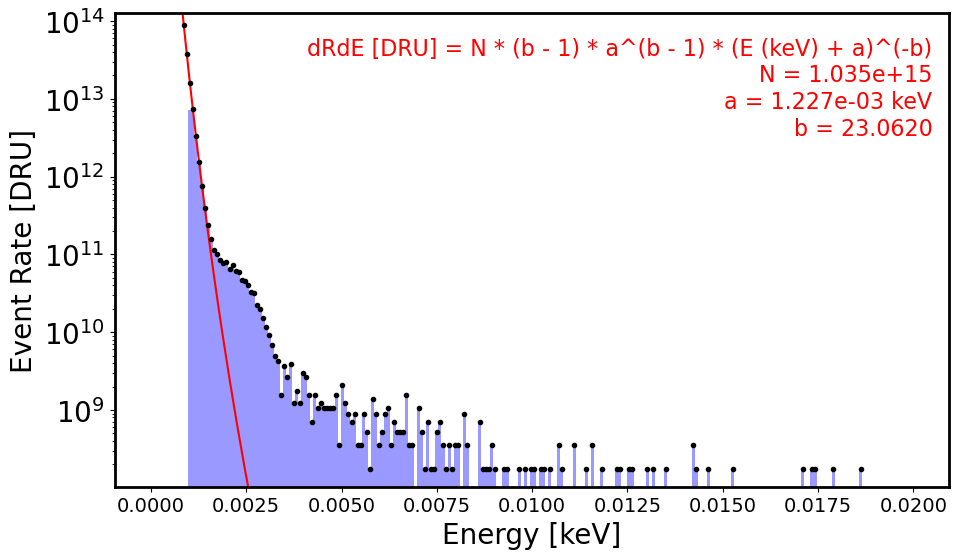

In [8]:
energies_eV = np.load('spectra/r57_1226_1mm_shared.npy')
energies_keV = energies_eV / 1000

bins_eV_upper = np.arange(0.5, 20, 0.08)
bins_eV_lower = np.arange(0, 0.5, 0.08)
bins_keV_upper = bins_eV_upper / 1000
bins_keV_lower = bins_eV_lower / 1000

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_upper)[0]))

dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_upper, weights=event_weights_DRU)
counts_arr, E_bin_edges_eV = np.histogram(energies_eV, bins_eV_upper)

E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
E_keV_arr = E_eV_arr / 1000

###### Combining ######

x_out = np.append(0.5 * (bins_keV_lower[1:] + bins_keV_lower[:-1]), E_keV_arr)
y_out = np.append(np.zeros(len(bins_keV_lower) - 1), dRdE_DRU_arr)
for i in range(len(x_out)):
    if x_out[i] < 0.002:
        y_out[i] = max(y_out[i], shifted_power_law_basic(x_out[i], N_fit_shifted, a_fit_shifted, b_fit_shifted) )
    
np.savetxt('combined_spectra_shared57.txt', np.column_stack((E_bin_edges_eV/1000, np.append(counts_arr, np.nan))), header='Energy [keV] dRdE [DRU]', fmt='%10.5e %10.5e')

####### Plotting #######

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.hist(energies_keV, bins_keV_upper, weights=event_weights_DRU, alpha=0.4, color='b')
ax.set_yscale('log')
ymin, ymax = ax.get_ylim()

keV_arr_fit = np.linspace(min(bins_keV_upper), max(bins_keV_upper), 200)

ax.plot(keV_arr_fit, shifted_power_law_basic(keV_arr_fit, N_fit_shifted, a_fit_shifted, b_fit_shifted), 'r-')
#ax.plot(E_keV_arr, dRdE_DRU_arr, 'ko', ms=3)
ax.plot(x_out, y_out, 'ko', ms=3)
ax.text(0.98, 0.95, f'dRdE [DRU] = N * (b - 1) * a^(b - 1) * (E (keV) + a)^(-b)\nN = {N_fit_shifted:.3e}\na = {a_fit_shifted:.3e} keV\nb = {b_fit_shifted:.4f}',
            ha='right', va='top', fontsize=16, color='r', transform=ax.transAxes)

ax.tick_params(axis='x', which='major', labelsize=14)

ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Event Rate [DRU]')
ax.set_ylim([ymin, ymax * 10])

fig.tight_layout()
fig.show()


## Medium-Energy Shared Fit

In [9]:
energies_eV = np.load('spectra/r57_1226_1mm_shared.npy')
energies_keV = energies_eV / 1000

bins_eV_full = np.arange(0.5, 20, 0.3)
bins_keV_full = bins_eV_full / 1000

# Do the fit in eV, then convert to keV (it converges better this way)
fit_low, fit_high = 4.5, 15
bins_eV_fit = bins_eV_full[(bins_eV_full > fit_low) * (bins_eV_full < fit_high)]

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

In [10]:
dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_fit, weights=event_weights_DRU)
counts_arr, _ = np.histogram(energies_eV, bins_eV_fit)

E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
E_keV_arr = E_eV_arr / 1000

Power law parameters (raw): A = 3.721e-01, alpha = -3.1139
Power law parameters [in proper units]: A = 7.922e+01 DRU, alpha = -3.1139

Exponential parameters [raw]: A = 1.567e+00, inverse E0 = 3.9485e-01 1/eV
Exponential parameters [in proper units]: A = 7.329e+09 DRU, E0 = 2.5326e-03 keV

Shifted Power law parameters [raw]: N = 7.241e-01, a = 0.0168 eV, b = 3.4709
Shifted Power law parameters [in keV]: N = 3.387e+12 DRU, a = 0.0000 keV, b = 3.4709



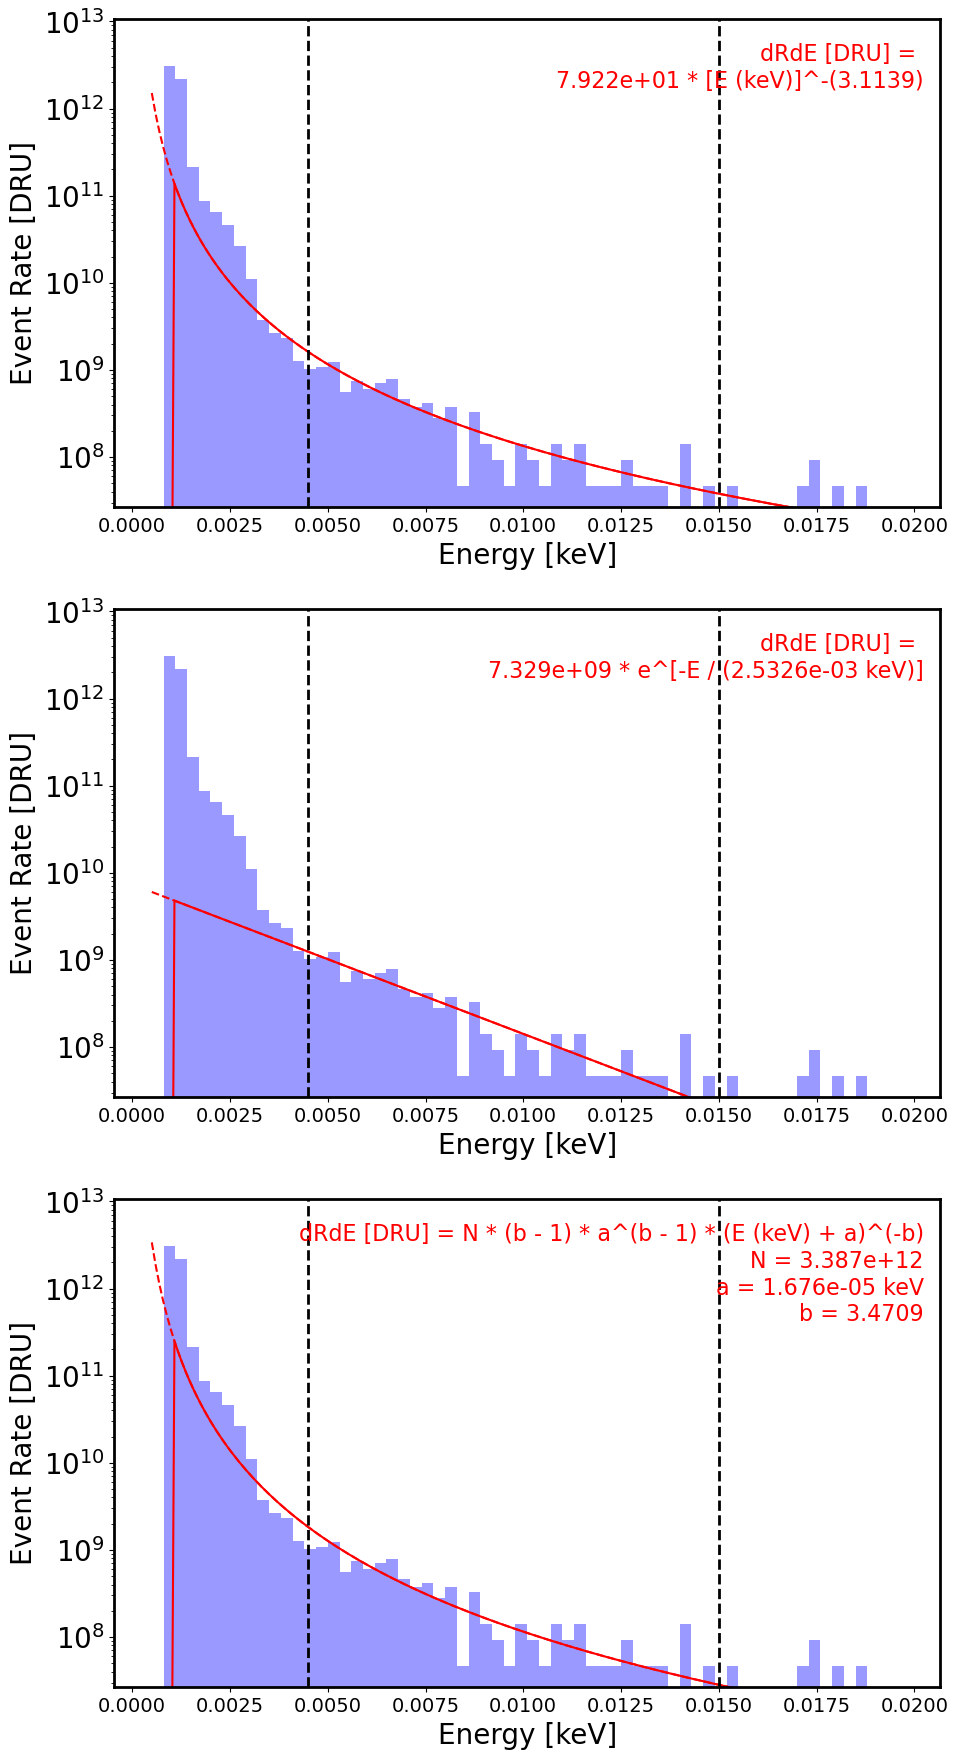

In [11]:
### Minimize the negative log likelihood for a power-law background
fit_scale = 1e4 # Divide the rate first to help the fit converge

# Do the fit in eV space to make it easier to fit, then convert to keV
result = minimize(negative_log_likelihood_power_basic,
                  [1, 10],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None)])
A_fit_power_me, alpha_fit_power_me = result.x
print(f"Power law parameters (raw): A = {A_fit_power_me:.3e}, alpha = -{alpha_fit_power_me:.4f}")

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
A_fit_power_me *= fit_scale * 1000**(-1 * alpha_fit_power_me) * event_weights_DRU[0] 
print(f"Power law parameters [in proper units]: A = {A_fit_power_me:.3e} DRU, alpha = -{alpha_fit_power_me:.4f}")
print('')



### Minimize the negative log likelihood for a exponential background
fit_scale = 1e2 # Divide the rate first to help the fit converge

# Do the fit in eV space to make it easier to fit, then convert to keV
result = minimize(negative_log_likelihood_exp_basic,
                  [1, 0.3],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None)])
A_fit_exp_me, inv_E0_exp_me = result.x
print(f"Exponential parameters [raw]: A = {A_fit_exp_me:.3e}, inverse E0 = {inv_E0_exp_me:.4e} 1/eV")

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
A_fit_exp_me *= fit_scale * event_weights_DRU[0]
inv_E0_exp_me *= 1000
print(f"Exponential parameters [in proper units]: A = {A_fit_exp_me:.3e} DRU, E0 = {1 / inv_E0_exp_me:.4e} keV")
print('')



### Minimize the negative log likelihood for a shifted power-law background
fit_scale = 1e8
result = minimize(negative_log_likelihood_shifted_power_basic,
                  [1, 1, 3.],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None), (1, None)])
N_fit_shifted_me, a_fit_shifted_me, b_fit_shifted_me = result.x
print(f"Shifted Power law parameters [raw]: N = {N_fit_shifted_me:.3e}, a = {a_fit_shifted_me:.4f} eV, b = {b_fit_shifted_me:.4f}")

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
N_fit_shifted_me *= fit_scale * (1/1000) * event_weights_DRU[0]
a_fit_shifted_me *= (1/1000)
print(f"Shifted Power law parameters [in keV]: N = {N_fit_shifted_me:.3e} DRU, a = {a_fit_shifted_me:.4f} keV, b = {b_fit_shifted_me:.4f}")
print('')



####### Plotting #######

fig, ax = plt.subplots(3, 1, figsize=(10, 18))

for i in range(3):
    ax[i].hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='b')
    ax[i].set_yscale('log')
    ymin, ymax = ax[i].get_ylim()

    keV_arr_fit = np.linspace(min(bins_keV_full), max(bins_keV_full), 200)
    
    if i == 0:
        ax[i].plot(keV_arr_fit, power_law(keV_arr_fit, A_fit_power_me, alpha_fit_power_me, Eth_power, inv_width_power), 'r-')
        ax[i].plot(keV_arr_fit, power_law_basic(keV_arr_fit, A_fit_power_me, alpha_fit_power_me), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_power_me:.3e} * [E (keV)]^-({alpha_fit_power_me:.4f})', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 1:
        ax[i].plot(keV_arr_fit, exponential(keV_arr_fit, A_fit_exp_me, inv_E0_exp_me, Eth_exp, inv_width_exp), 'r-')
        ax[i].plot(keV_arr_fit, exponential_basic(keV_arr_fit, A_fit_exp_me, inv_E0_exp_me), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_exp_me:.3e} * e^[-E / ({1/inv_E0_exp_me:.4e} keV)]', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 2:
        #ax[i].set_xscale('log')
        #ax[i].plot(keV_arr_fit, shifted_power_law(keV_arr_fit, 1e16, 3e-4, 12, 1e-3, 1e6), 'r-')
        ax[i].plot(keV_arr_fit, shifted_power_law(keV_arr_fit, N_fit_shifted_me, a_fit_shifted_me, b_fit_shifted_me, Eth_shifted, inv_width_shifted), 'r-')
        ax[i].plot(keV_arr_fit, shifted_power_law_basic(keV_arr_fit, N_fit_shifted_me, a_fit_shifted_me, b_fit_shifted_me), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = N * (b - 1) * a^(b - 1) * (E (keV) + a)^(-b)\nN = {N_fit_shifted_me:.3e}\na = {a_fit_shifted_me:.3e} keV\nb = {b_fit_shifted_me:.4f}',
                   ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)

    #ax[i].text(3, 5e11, f'Fit Region', ha='right', va='top', fontsize=24, color='k')

    ax[i].set_xlabel('Energy [keV]')
    ax[i].set_ylabel('Event Rate [DRU]')

    ax[i].plot([fit_low/1e3, fit_low/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].plot([fit_high/1e3, fit_high/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].set_ylim([ymin, ymax*2])
    
    ax[i].tick_params(axis='x', which='major', labelsize=14)


fig.tight_layout()
fig.show()


## Residual Peak

In [12]:
energies_eV = np.load('spectra/r57_1226_1mm_shared.npy')
energies_keV = energies_eV / 1000

bins_eV_full = np.arange(0., 20, 0.1)
bins_keV_full = bins_eV_full / 1000

# Do the fit in eV, then convert to keV (it converges better this way)
fit_low, fit_high = 4.5, 15
bins_eV_fit = bins_eV_full[(bins_eV_full > fit_low) * (bins_eV_full < fit_high)]

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

In [13]:
dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_fit, weights=event_weights_DRU)
counts_arr, _ = np.histogram(energies_eV, bins_eV_fit)

E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
E_keV_arr = E_eV_arr / 1000

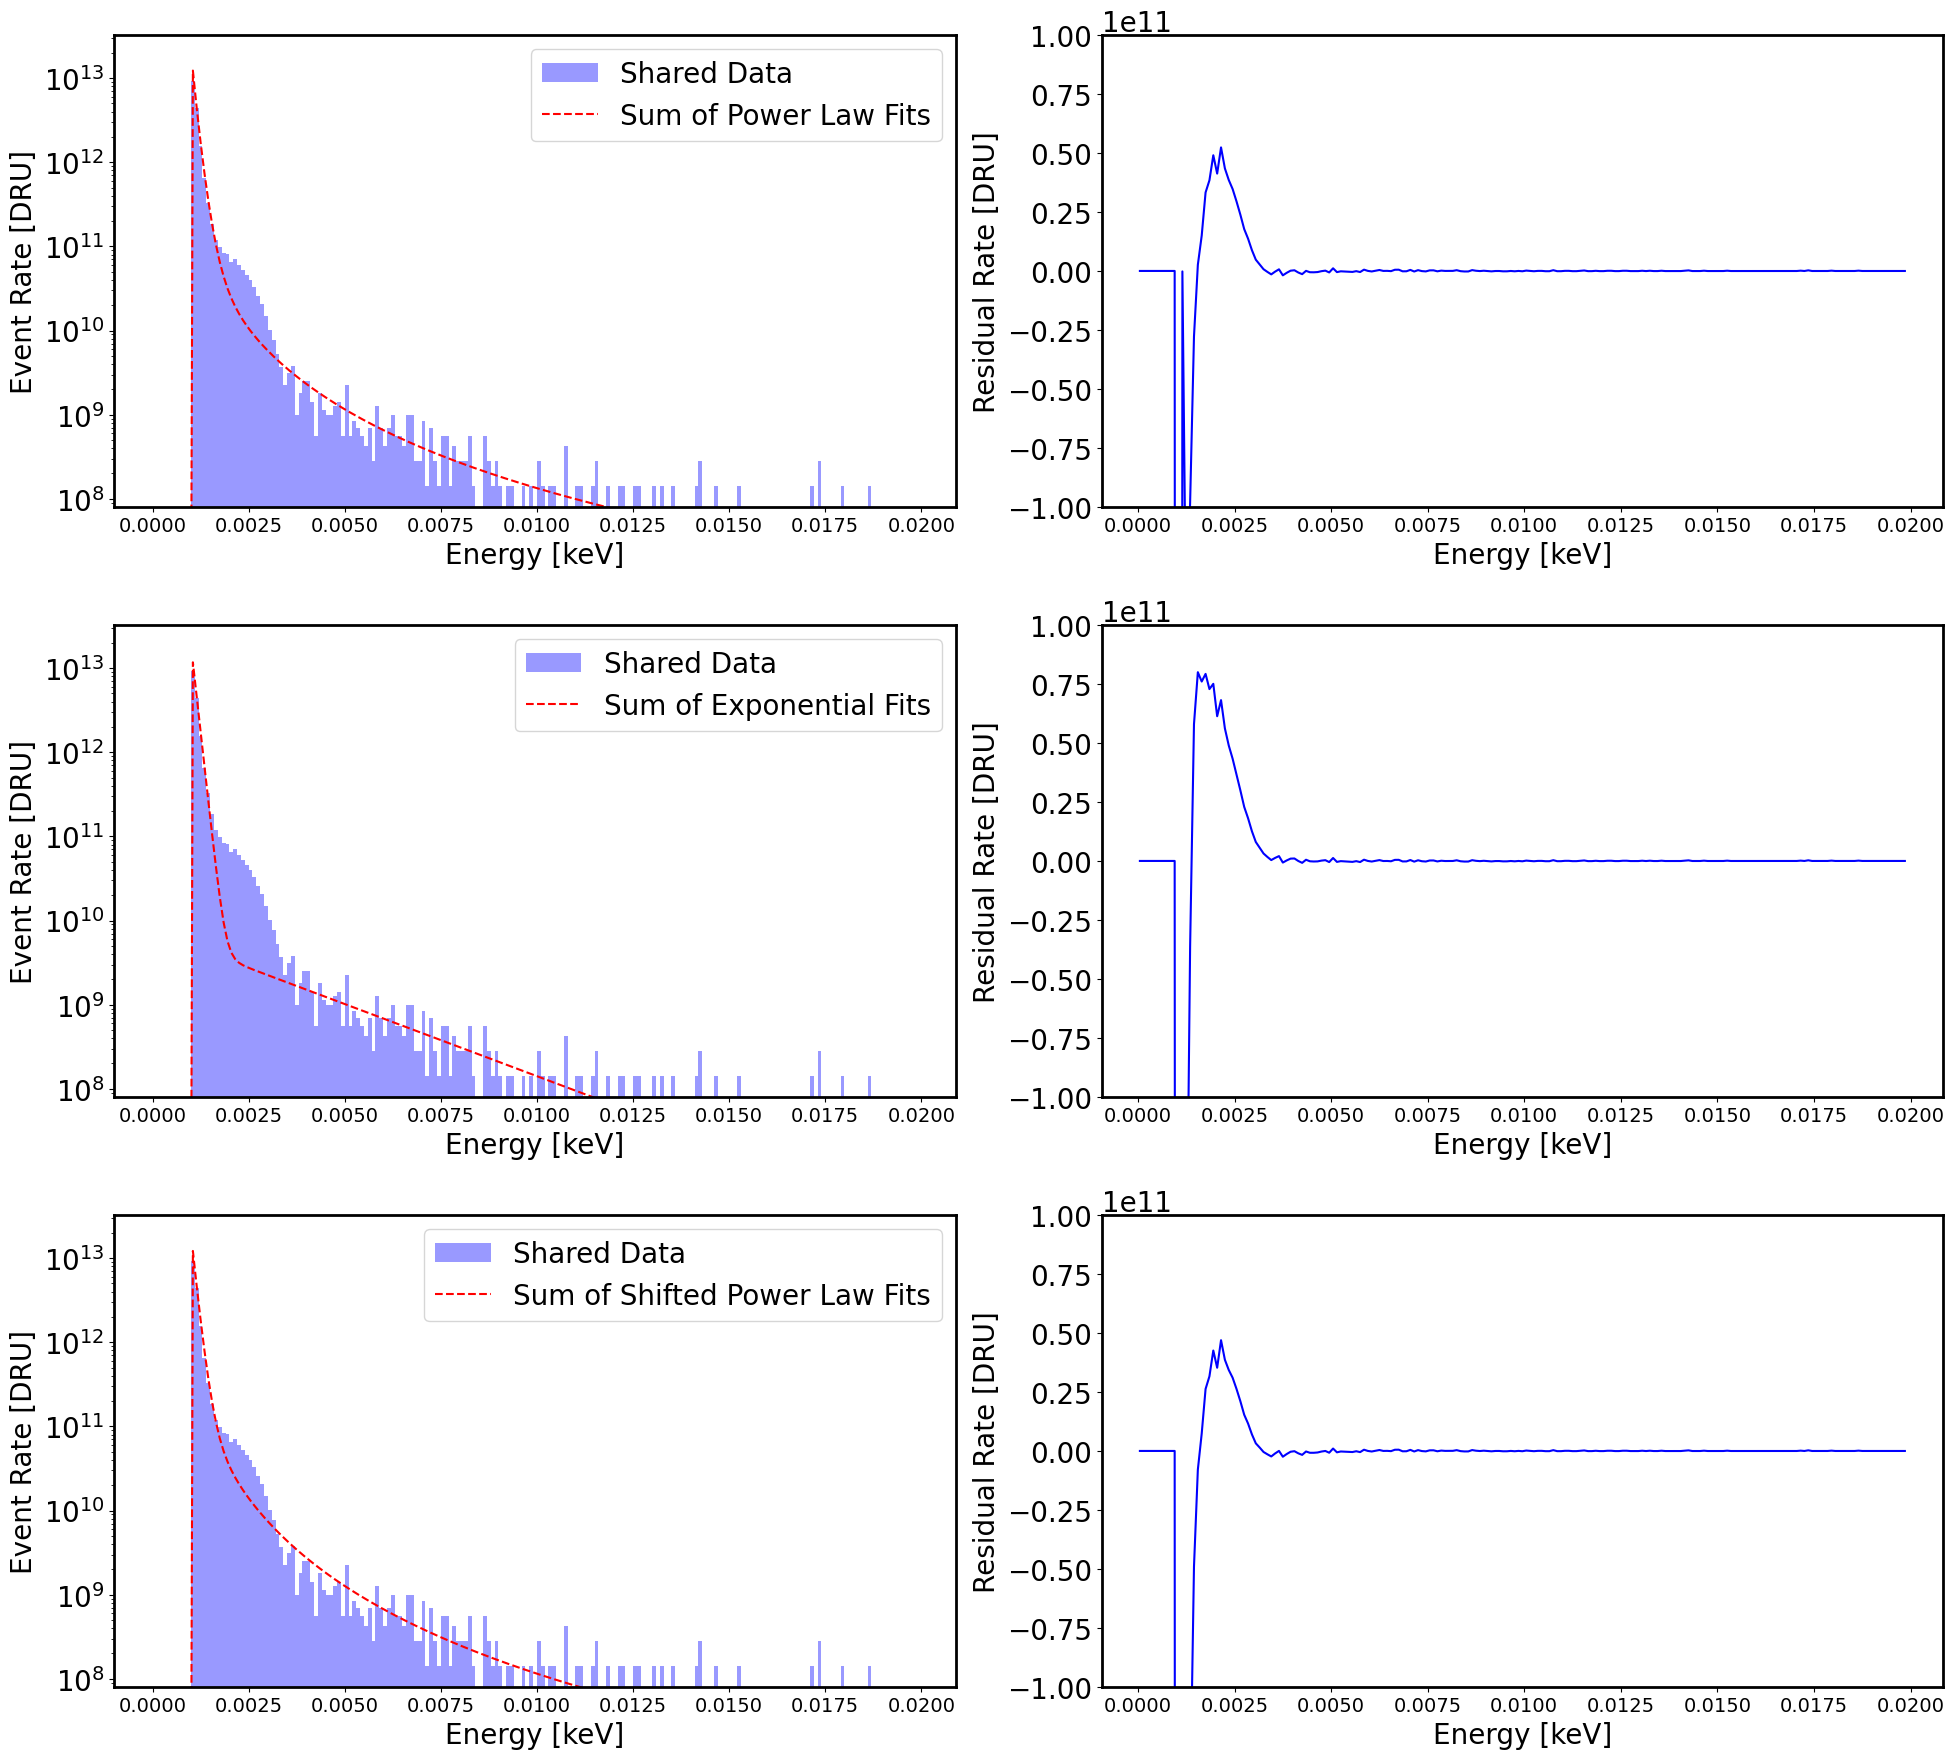

In [14]:
energies_eV = np.load('spectra/r57_1226_1mm_shared.npy')
energies_keV = energies_eV / 1000

bins_eV_full = np.arange(0., 20, 0.1)
bins_keV_full = bins_eV_full / 1000

# Do the fit in eV, then convert to keV (it converges better this way)
fit_low, fit_high = 4.5, 15
bins_eV_fit = bins_eV_full[(bins_eV_full > fit_low) * (bins_eV_full < fit_high)]

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_fit, weights=event_weights_DRU)
counts_arr, _ = np.histogram(energies_eV, bins_eV_fit)

E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
E_keV_arr = E_eV_arr / 1000

####### Plotting #######

fig, ax = plt.subplots(3, 2, figsize=(20, 18))

for i in range(3):

    # Calculate histogram
    hist, bin_edges = np.histogram(energies_keV, bins_keV_full, weights=event_weights_DRU)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    # Plot histogram of real data
    ax[i,0].hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='b', label='Shared Data')
    ax[i,0].set_yscale('log')
    ymin, ymax = ax[i,0].get_ylim()

    if i == 0:
        ax[i,0].plot(bin_centers, power_law(bin_centers, A_fit_power, alpha_fit_power, Eth_power, inv_width_power) + power_law(bin_centers, A_fit_power_me, alpha_fit_power_me, Eth_power, inv_width_power), 'r--', label='Sum of Power Law Fits')
        ax[i,1].plot(bin_centers, hist - power_law(bin_centers, A_fit_power, alpha_fit_power, Eth_power, inv_width_power) - power_law(bin_centers, A_fit_power_me, alpha_fit_power_me, Eth_power, inv_width_power), 'b-')
    elif i == 1:
        ax[i,0].plot(bin_centers, exponential(bin_centers, A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp) + exponential(bin_centers, A_fit_exp_me, inv_E0_exp_me, Eth_exp, inv_width_exp), 'r--', label='Sum of Exponential Fits')
        ax[i,1].plot(bin_centers, hist - exponential(bin_centers, A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp) - exponential(bin_centers, A_fit_exp_me, inv_E0_exp_me, Eth_exp, inv_width_exp), 'b-')
    elif i == 2:
        ax[i,0].plot(bin_centers, shifted_power_law(bin_centers, N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted) + shifted_power_law(bin_centers, N_fit_shifted_me, a_fit_shifted_me, b_fit_shifted_me, Eth_shifted, inv_width_shifted), 'r--', label='Sum of Shifted Power Law Fits')
        ax[i,1].plot(bin_centers, hist - shifted_power_law(bin_centers, N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted) - shifted_power_law(bin_centers, N_fit_shifted_me, a_fit_shifted_me, b_fit_shifted_me, Eth_shifted, inv_width_shifted), 'b-')

    ax[i,0].set_ylim([ymin, ymax * 2])
    ax[i,0].set_xlabel('Energy [keV]')
    ax[i,0].set_ylabel('Event Rate [DRU]')
    ax[i,0].tick_params(axis='x', which='major', labelsize=14)
    ax[i,0].legend(loc='best')
    ax[i,1].set_xlabel('Energy [keV]')
    ax[i,1].set_ylabel('Residual Rate [DRU]')
    ax[i,1].set_ylim([-1e11, 1e11])
    ax[i,1].tick_params(axis='x', which='major', labelsize=14)

fig.tight_layout()
fig.show()

####### Plotting #######


## Singles Low-Energy Fit

In [15]:
energies_eV = np.load('spectra/r57_1226_1mm_single_left.npy') / 0.4 # PCE estimate
energies_keV = energies_eV / 1000

bins_eV_full = np.arange(0.1, 5, 0.02)
bins_keV_full = bins_eV_full / 1000

# Do the fit in eV, then convert to keV (it converges better this way)
fit_low, fit_high = 0.4, 1.4
bins_eV_fit = bins_eV_full[(bins_eV_full > fit_low) * (bins_eV_full < fit_high)]

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

In [16]:
dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_fit, weights=event_weights_DRU)
counts_arr, _ = np.histogram(energies_eV, bins_eV_fit)

E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
E_keV_arr = E_eV_arr / 1000

Power law parameters (raw): A = 3.633e-02, alpha = -6.0152
Threshold = 5.220e-01 eV, inverse width = 5.00000e+02 1/eV
Power law parameters [in proper units]: A = 2.295e-07 DRU, alpha = -6.0152
Threshold = 5.220e-04 keV, width = 2.00000e-06 keV

Exponential parameters [raw]: A = 9.595e-01, inverse E0 = 7.9711e+00 1/eV
Threshold = 5.212e-01 eV, inverse width = 5.00000e+02 1/eV
Exponential parameters [in proper units]: A = 6.732e+14 DRU, E0 = 1.2545e-04 keV
Threshold = 5.212e-04 keV, width = 2.0000e-06 keV

Shifted Power law parameters [raw]: N = 4.535e-01, a = 0.1006 eV, b = 6.5336
Threshold = 5.216e-01 eV, inverse width = 5.00000e+02 1/eV
Shifted Power law parameters [in keV]: N = 3.182e+13 DRU, a = 0.0001 keV, b = 6.5336
Threshold = 5.216e-04 eV, width = 2.00000e-06 eV



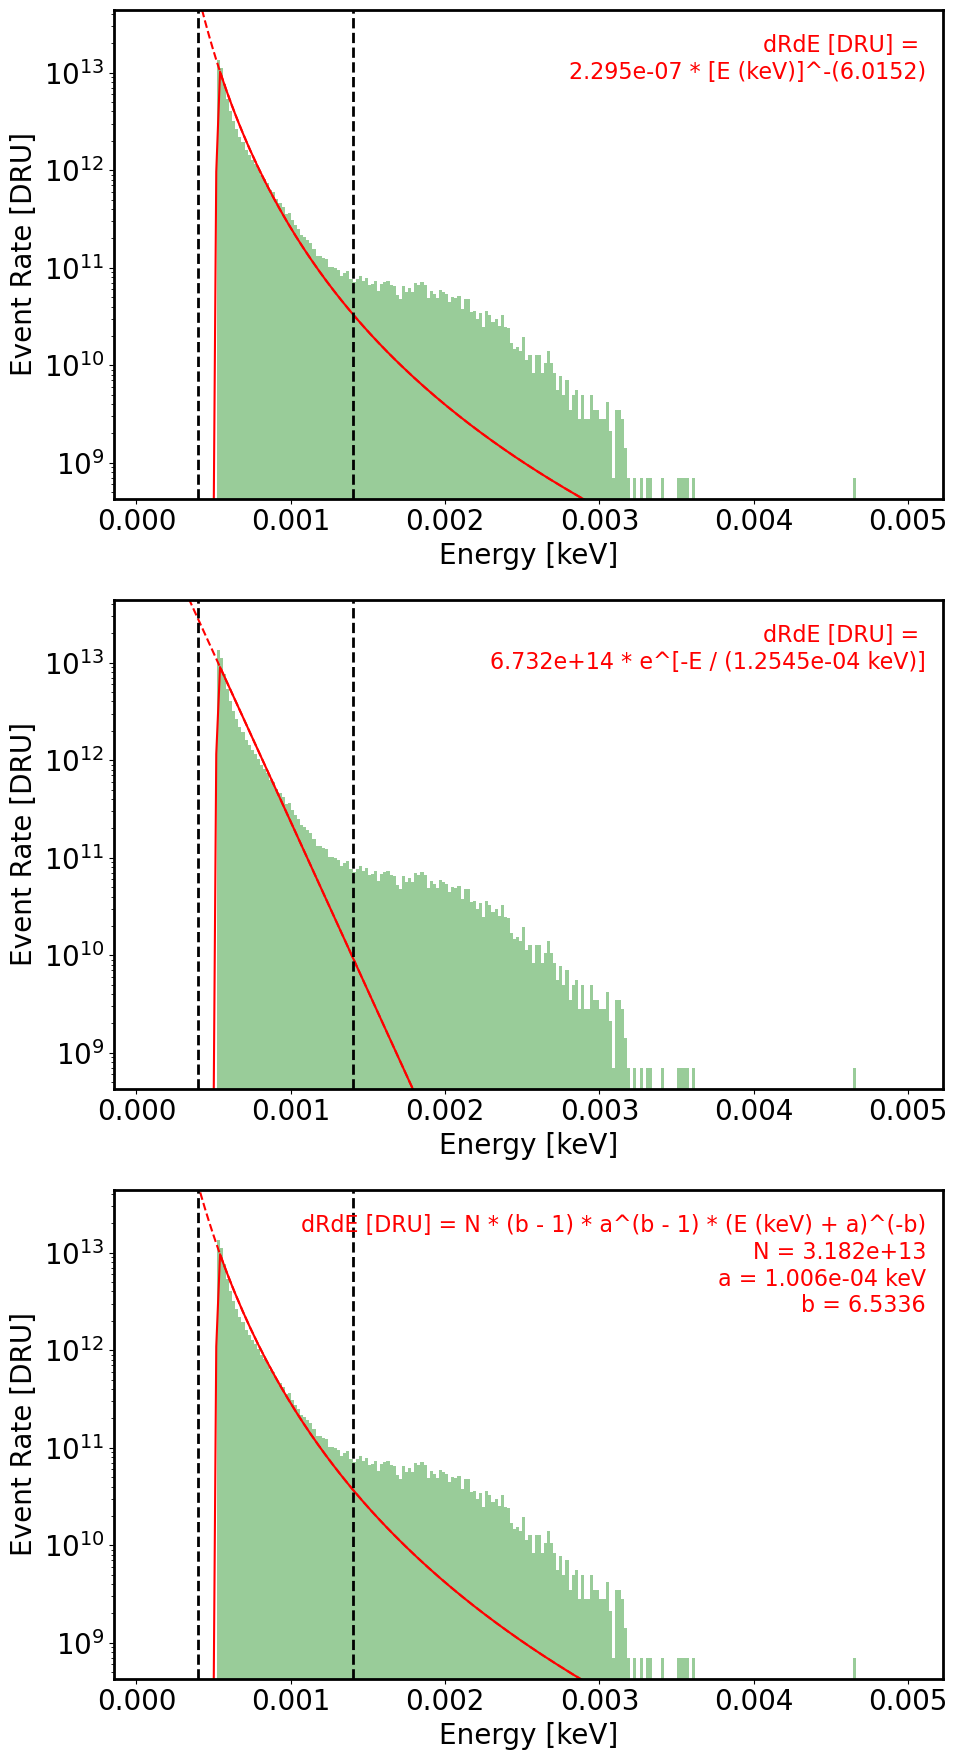

In [17]:
### Minimize the negative log likelihood for a power-law background
fit_scale = 1e4 # Divide the rate first to help the fit converge

# Do the fit in eV space to make it easier to fit, then convert to keV
result = minimize(negative_log_likelihood_power,
                  [1, 6, 0.5, 500],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None), (0.5, 1.5), (1e-10, None)])
A_fit_power, alpha_fit_power, Eth_power, inv_width_power = result.x
print(f"Power law parameters (raw): A = {A_fit_power:.3e}, alpha = -{alpha_fit_power:.4f}")
print(f'Threshold = {Eth_power:.3e} eV, inverse width = {inv_width_power:.5e} 1/eV')

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
A_fit_power *= fit_scale * 1000**(-1 * alpha_fit_power) * event_weights_DRU[0] 
Eth_power *= (1/1000)
inv_width_power *= 1000
print(f"Power law parameters [in proper units]: A = {A_fit_power:.3e} DRU, alpha = -{alpha_fit_power:.4f}")
print(f'Threshold = {Eth_power:.3e} keV, width = {1 / inv_width_power:.5e} keV')
print('')



### Minimize the negative log likelihood for a exponential background
fit_scale = 1e6 # Divide the rate first to help the fit converge

# Do the fit in eV space to make it easier to fit, then convert to keV
result = minimize(negative_log_likelihood_exp,
                  [1, 1, 0.5, 500],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None), (0.5, 1.5), (1e-10, None)])
A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp = result.x
print(f"Exponential parameters [raw]: A = {A_fit_exp:.3e}, inverse E0 = {inv_E0_exp:.4e} 1/eV")
print(f'Threshold = {Eth_exp:.3e} eV, inverse width = {inv_width_exp:.5e} 1/eV')

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
A_fit_exp *= fit_scale * event_weights_DRU[0]
inv_E0_exp *= 1000
Eth_exp *= (1/1000)
inv_width_exp *= 1000
print(f"Exponential parameters [in proper units]: A = {A_fit_exp:.3e} DRU, E0 = {1 / inv_E0_exp:.4e} keV")
print(f'Threshold = {Eth_exp:.3e} keV, width = {1 / inv_width_exp:.4e} keV')
print('')



### Minimize the negative log likelihood for a shifted power-law background
fit_scale = 1e8
result = minimize(negative_log_likelihood_shifted_power,
                  [1, 0.5, 6., 0.5, 500.],
                  args=(E_eV_arr, counts_arr/fit_scale),
                  method='L-BFGS-B',
                  bounds=[(1e-10, None), (1e-10, None), (1, None), (0.5, 1.5), (1e-10, None)])
N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted = result.x
print(f"Shifted Power law parameters [raw]: N = {N_fit_shifted:.3e}, a = {a_fit_shifted:.4f} eV, b = {b_fit_shifted:.4f}")
print(f'Threshold = {Eth_shifted:.3e} eV, inverse width = {inv_width_shifted:.5e} 1/eV')

# Rescale to the original units: update fit scale, then eV to keV, then counts to DRU
N_fit_shifted *= fit_scale * (1/1000) * event_weights_DRU[0]
a_fit_shifted *= (1/1000)
Eth_shifted *= (1/1000)
inv_width_shifted *= 1000
print(f"Shifted Power law parameters [in keV]: N = {N_fit_shifted:.3e} DRU, a = {a_fit_shifted:.4f} keV, b = {b_fit_shifted:.4f}")
print(f'Threshold = {Eth_shifted:.3e} eV, width = {1 / inv_width_shifted:.5e} eV')
print('')



####### Plotting #######

fig, ax = plt.subplots(3, 1, figsize=(10, 18))

for i in range(3):
    ax[i].hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='g')
    ax[i].set_yscale('log')
    ymin, ymax = ax[i].get_ylim()

    keV_arr_fit = np.linspace(min(bins_keV_full), max(bins_keV_full), 200)
    
    if i == 0:
        ax[i].plot(keV_arr_fit, power_law(keV_arr_fit, A_fit_power, alpha_fit_power, Eth_power, inv_width_power), 'r-')
        ax[i].plot(keV_arr_fit, power_law_basic(keV_arr_fit, A_fit_power, alpha_fit_power), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_power:.3e} * [E (keV)]^-({alpha_fit_power:.4f})', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 1:
        ax[i].plot(keV_arr_fit, exponential(keV_arr_fit, A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp), 'r-')
        ax[i].plot(keV_arr_fit, exponential_basic(keV_arr_fit, A_fit_exp, inv_E0_exp), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = \n{A_fit_exp:.3e} * e^[-E / ({1/inv_E0_exp:.4e} keV)]', ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)
    elif i == 2:
        #ax[i].set_xscale('log')
        #ax[i].plot(keV_arr_fit, shifted_power_law(keV_arr_fit, 1e16, 3e-4, 12, 1e-3, 1e6), 'r-')
        ax[i].plot(keV_arr_fit, shifted_power_law(keV_arr_fit, N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted), 'r-')
        ax[i].plot(keV_arr_fit, shifted_power_law_basic(keV_arr_fit, N_fit_shifted, a_fit_shifted, b_fit_shifted), 'r--')
        ax[i].text(0.98, 0.95, f'dRdE [DRU] = N * (b - 1) * a^(b - 1) * (E (keV) + a)^(-b)\nN = {N_fit_shifted:.3e}\na = {a_fit_shifted:.3e} keV\nb = {b_fit_shifted:.4f}',
                   ha='right', va='top', fontsize=16, color='r', transform=ax[i].transAxes)

    #ax[i].text(3, 5e11, f'Fit Region', ha='right', va='top', fontsize=24, color='k')

    ax[i].set_xlabel('Energy [keV]')
    ax[i].set_ylabel('Event Rate [DRU]')

    ax[i].plot([fit_low/1e3, fit_low/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].plot([fit_high/1e3, fit_high/1e3], [ymin, ymax*2], 'k--', lw=2)
    ax[i].set_ylim([ymin, ymax*2])

fig.tight_layout()
fig.show()


## Save histogram to text file

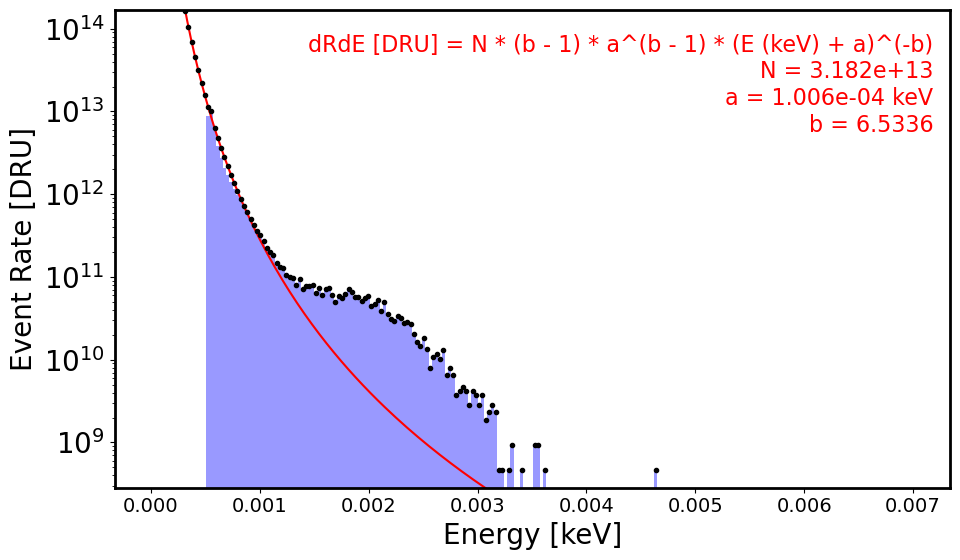

In [18]:
energies_eV = np.load('spectra/r57_1226_1mm_single_left.npy') / 0.4 # PCE estimate
energies_keV = energies_eV / 1000

bins_eV_upper = np.arange(0.3, 7, 0.03)
bins_eV_lower = np.arange(0, 0.3, 0.03)
bins_keV_upper = bins_eV_upper / 1000
bins_keV_lower = bins_eV_lower / 1000

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_upper)[0]))

dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_upper, weights=event_weights_DRU)
counts_arr, E_bin_edges_eV = np.histogram(energies_eV, bins_eV_upper)

E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
E_keV_arr = E_eV_arr / 1000

###### Combining ######

x_out = np.append(0.5 * (bins_keV_lower[1:] + bins_keV_lower[:-1]), E_keV_arr)
y_out = np.append(np.zeros(len(bins_keV_lower) - 1), dRdE_DRU_arr)
for i in range(len(x_out)):
    if x_out[i] < 0.002:
        y_out[i] = max(y_out[i], shifted_power_law_basic(x_out[i], N_fit_shifted, a_fit_shifted, b_fit_shifted) )
    
np.savetxt('combined_spectra_singles57.txt', np.column_stack((E_bin_edges_eV, np.append(counts_arr, np.nan))), header='Phonon Energy [keV] dRdE [DRU]', fmt='%10.5e %10.5e')

####### Plotting #######

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.hist(energies_keV, bins_keV_upper, weights=event_weights_DRU, alpha=0.4, color='b')
ax.set_yscale('log')
ymin, ymax = ax.get_ylim()

keV_arr_fit = np.linspace(min(bins_keV_upper), max(bins_keV_upper), 200)

ax.plot(keV_arr_fit, shifted_power_law_basic(keV_arr_fit, N_fit_shifted, a_fit_shifted, b_fit_shifted), 'r-')
#ax.plot(E_keV_arr, dRdE_DRU_arr, 'ko', ms=3)
ax.plot(x_out, y_out, 'ko', ms=3)
ax.text(0.98, 0.95, f'dRdE [DRU] = N * (b - 1) * a^(b - 1) * (E (keV) + a)^(-b)\nN = {N_fit_shifted:.3e}\na = {a_fit_shifted:.3e} keV\nb = {b_fit_shifted:.4f}',
            ha='right', va='top', fontsize=16, color='r', transform=ax.transAxes)

ax.tick_params(axis='x', which='major', labelsize=14)

ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Event Rate [DRU]')
ax.set_ylim([ymin, ymax * 10])

fig.tight_layout()
fig.show()


## Residual from Singles

In [19]:
energies_eV = np.load('spectra/r57_1226_1mm_single_left.npy') / 0.4 # PCE estimate
energies_keV = energies_eV / 1000

bins_eV_full = np.arange(0., 20, 0.1)
bins_keV_full = bins_eV_full / 1000

# Weights need to be recalculated when binning changes
event_weights_DRU = np.full(len(energies_eV), (1/mass_kg/time_days/np.diff(bins_keV_full)[0]))

In [20]:
dRdE_DRU_arr, E_eV_arr = np.histogram(energies_eV, bins_eV_fit, weights=event_weights_DRU)
counts_arr, _ = np.histogram(energies_eV, bins_eV_fit)

E_eV_arr = 0.5 * (E_eV_arr[1:] + E_eV_arr[:-1])
E_keV_arr = E_eV_arr / 1000


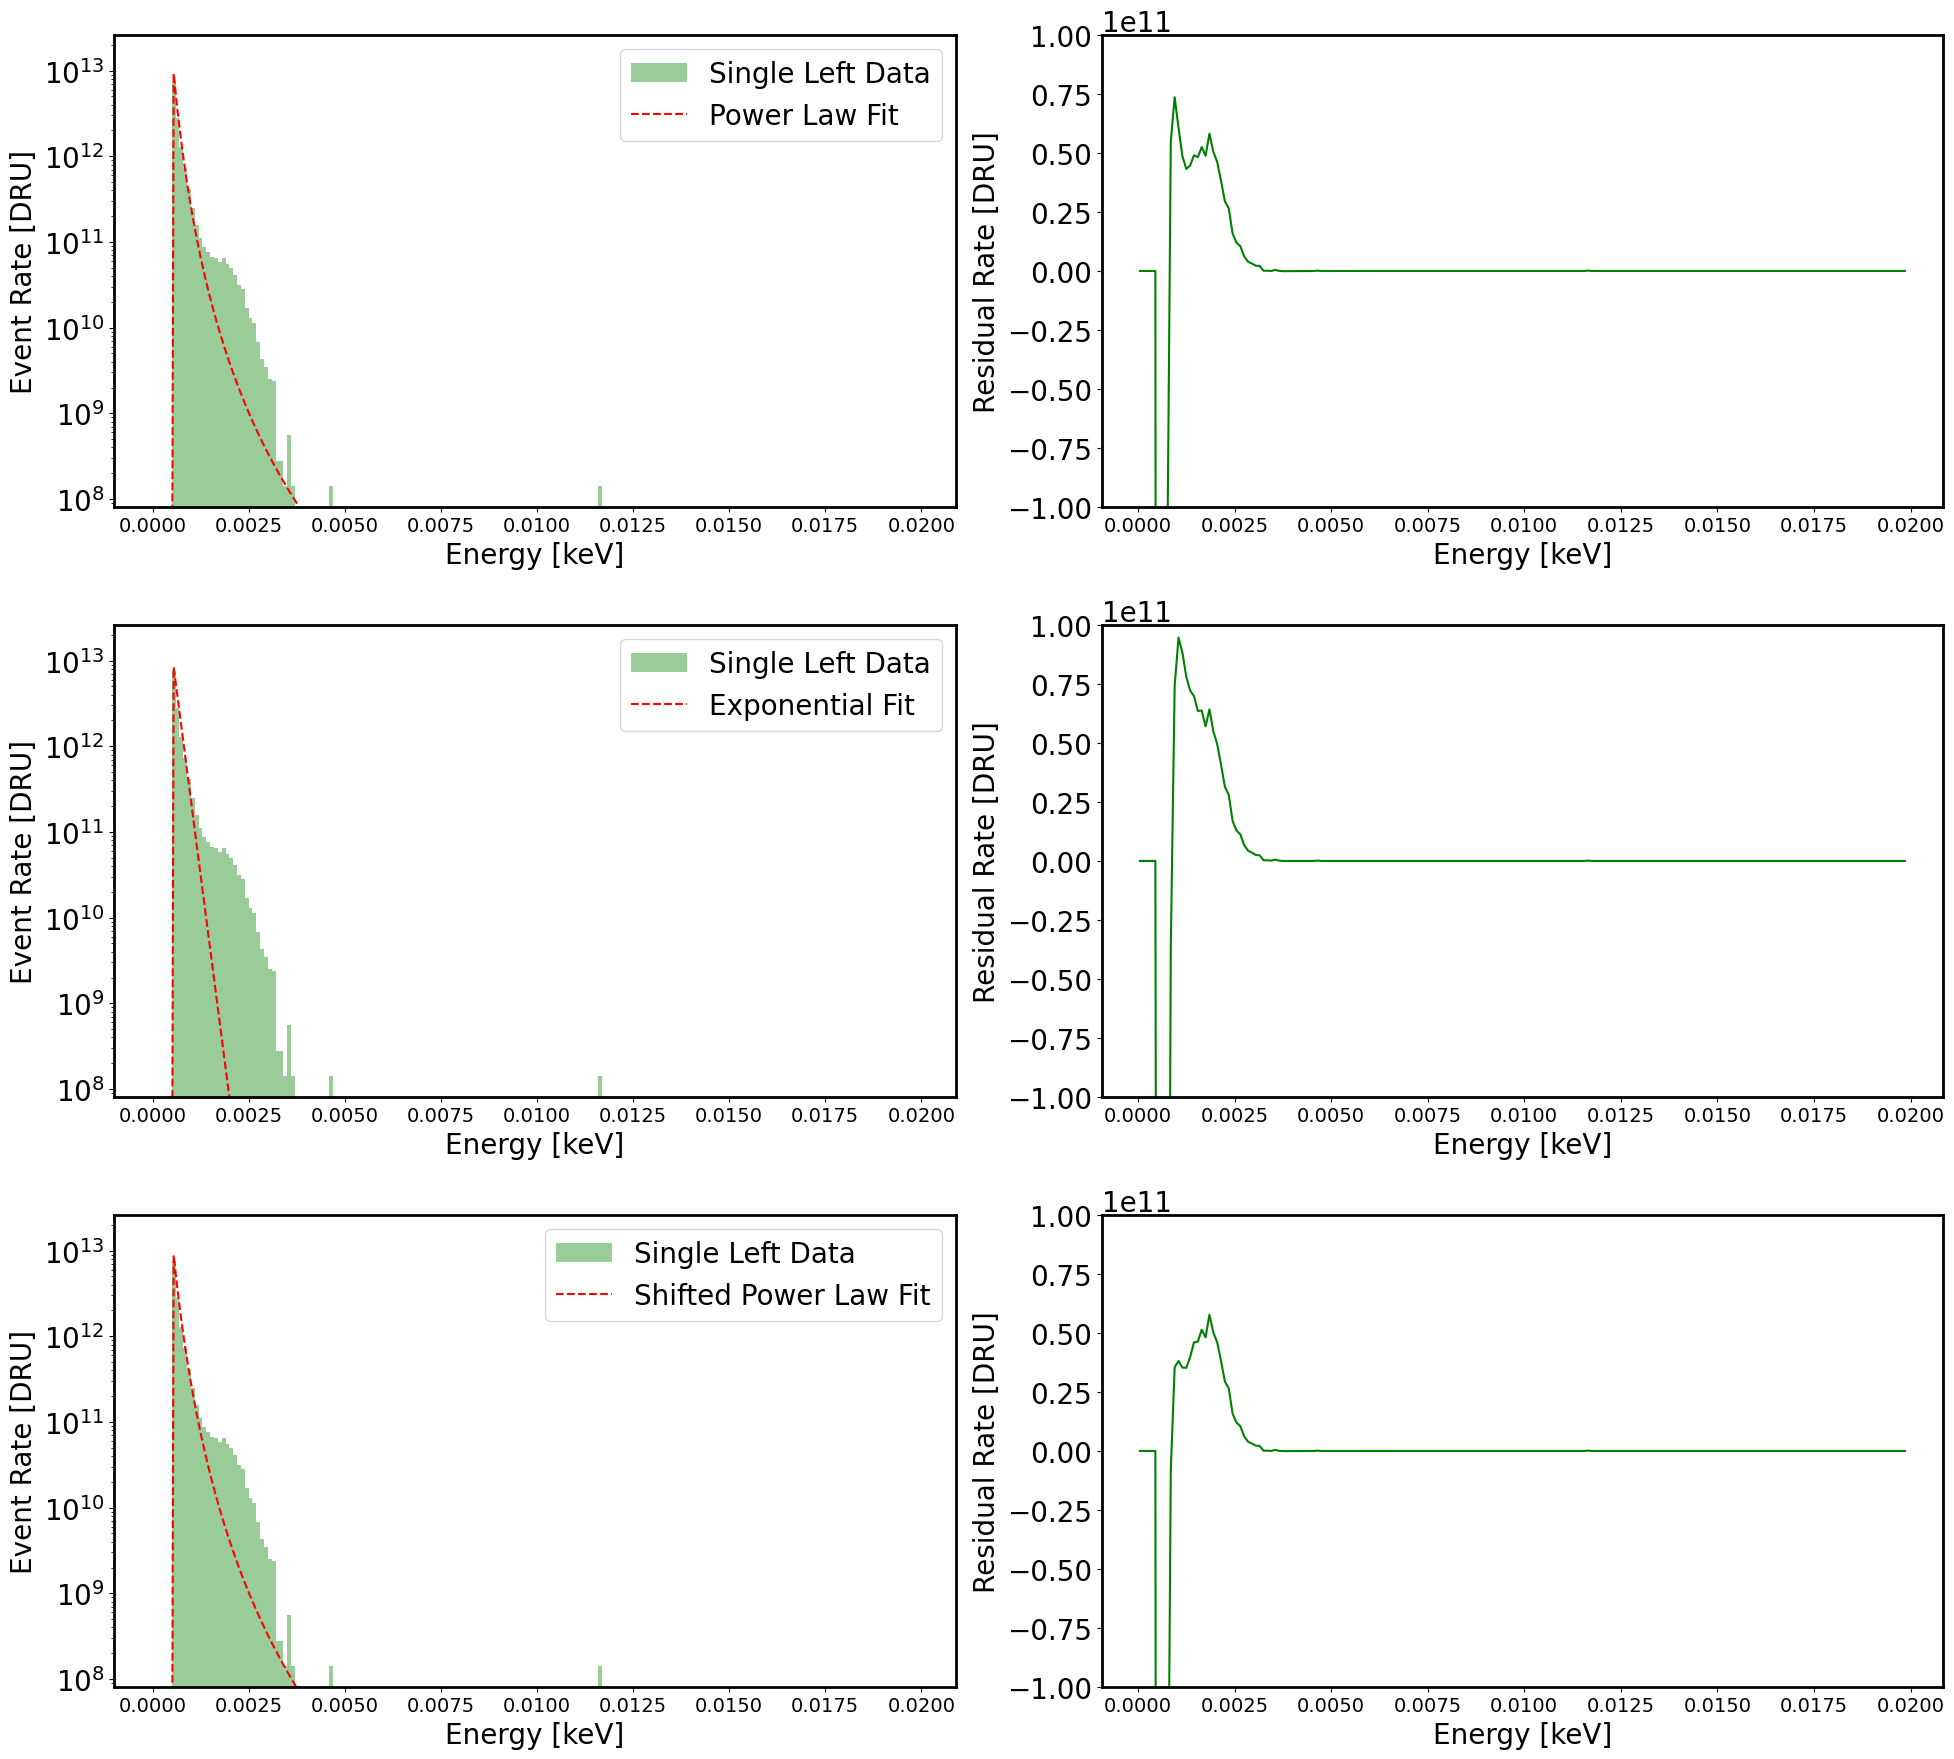

In [21]:
####### Plotting #######

fig, ax = plt.subplots(3, 2, figsize=(20, 18))

for i in range(3):

    # Calculate histogram
    hist, bin_edges = np.histogram(energies_keV, bins_keV_full, weights=event_weights_DRU)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    # Plot histogram of real data
    ax[i,0].hist(energies_keV, bins_keV_full, weights=event_weights_DRU, alpha=0.4, color='g', label='Single Left Data')
    ax[i,0].set_yscale('log')
    ymin, ymax = ax[i,0].get_ylim()

    if i == 0:
        ax[i,0].plot(bin_centers, power_law(bin_centers, A_fit_power, alpha_fit_power, Eth_power, inv_width_power), 'r--', label='Power Law Fit')
        ax[i,1].plot(bin_centers, hist - power_law(bin_centers, A_fit_power, alpha_fit_power, Eth_power, inv_width_power), 'g-')
    elif i == 1:
        ax[i,0].plot(bin_centers, exponential(bin_centers, A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp), 'r--', label='Exponential Fit')
        ax[i,1].plot(bin_centers, hist - exponential(bin_centers, A_fit_exp, inv_E0_exp, Eth_exp, inv_width_exp), 'g-')
    elif i == 2:
        ax[i,0].plot(bin_centers, shifted_power_law(bin_centers, N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted), 'r--', label='Shifted Power Law Fit')
        ax[i,1].plot(bin_centers, hist - shifted_power_law(bin_centers, N_fit_shifted, a_fit_shifted, b_fit_shifted, Eth_shifted, inv_width_shifted), 'g-')

    ax[i,0].set_ylim([ymin, ymax * 2])
    ax[i,0].set_xlabel('Energy [keV]')
    ax[i,0].set_ylabel('Event Rate [DRU]')
    ax[i,0].tick_params(axis='x', which='major', labelsize=14)
    ax[i,0].legend(loc='best')
    ax[i,1].set_xlabel('Energy [keV]')
    ax[i,1].set_ylabel('Residual Rate [DRU]')
    ax[i,1].set_ylim([-1e11, 1e11])
    ax[i,1].tick_params(axis='x', which='major', labelsize=14)

fig.tight_layout()
fig.show()

####### Plotting #######
